# Classifieur de phrases parallèles — Régression logistique

Ce notebook entraîne un modèle de régression logistique afin d'identifier automatiquement des paires de phrases **parallèles** ou **semi-parallèles** entre le français et les langues régionales de France (alsacien, corse, occitan).

Il s'appuie sur le fichier `similarity_dataset.csv` produit par le notebook précédent, qui contient pour chaque paire :
- un score de similarité sémantique SBERT,
- un score de longueur,
- des indices de Jaccard sur les n-grammes de caractères (bigrammes, trigrammes, quadrigrammes),
- un indice de Jaccard phonétique (Metaphone),
- une étiquette de classe : `parallel`, `semi-parallel`, ou `non-parallel`.

**Pipeline :**
1. Chargement et exploration des données
2. Préparation des variables d'apprentissage
3. Entraînement du modèle (binaire et multiclasse)
4. Évaluation et analyse des résultats
5. Sauvegarde du modèle
6. Fonction d'inférence sur de nouvelles paires

## 0. Imports et configuration

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import unicodedata
import string
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.pipeline import Pipeline

# -------------------------------------------------------
# Configuration
# -------------------------------------------------------
DATASET_PATH   = "similarity_dataset.csv"
MODEL_BIN_PATH = "logreg_binary.joblib"       # modèle binaire (parallèle vs non-parallèle)
MODEL_MC_PATH  = "logreg_multiclass.joblib"   # modèle multiclasse (3 classes)
SCALER_PATH    = "scaler.joblib"
RANDOM_STATE   = 42
TEST_SIZE      = 0.2

FEATURE_COLS = [
    "sbert_score",
    "length_score",
    "jaccard_bigrams",
    "jaccard_trigrams",
    "jaccard_quadrigrams",
    "phonetic_jaccard",
]

print("Imports OK — configuration chargée.")

Imports OK — configuration chargée.


## 1. Chargement et exploration des données

In [8]:
df = pd.read_csv(DATASET_PATH, encoding="utf-8-sig")
print(f"Dimensions : {df.shape[0]} paires × {df.shape[1]} colonnes")
df.head(3)

Dimensions : 3435 paires × 13 colonnes


,fr_sentence,lr_sentence,language_pair,class,binary_class,sbert_score,length_score,jaccard_bigrams,jaccard_trigrams,jaccard_quadrigrams,phonetic_jaccard,corpus,language
0,L'enseignement élémentaire est obligatoire.,"• Cunsigliu di l’Europa, Cunvenzione europea d...",parcolab_universal_tr__fr-gsw,non-parallel,0,0.249891,0.950617,0.124183,0.021605,0.007282,0.000,parcolab_universal_tr_,gsw
1,"Alors, la bise s'est mise à souffler de toute ...","A quau moment, la bisa se metèt a bofar, tant ...",LIMSI_fr-oc_noc_sannat,parallel,1,0.698508,0.051282,0.445455,0.228571,0.130597,0.225,LIMSI_fr-oc_noc,sannat
2,1.,1.,parcolab_universal_tr__fr-co,semi-parallel,1,1.000000,0.000000,0.000000,0.000000,0.000000,0.000,parcolab_universal_tr_,co


In [9]:
print("=== Distribution des classes ===")
print(df["class"].value_counts().to_string())

print("\n=== Distribution par langue ===")
# Regroupe les variétés dialectales en 3 grandes langues régionales
regional_map = {
    "co":  "Corse",
    "gsw": "Alsacien",
    "oc":  "Occitan",
}

def map_language(lang):
    if lang in regional_map:
        return regional_map[lang]
    # Les variétés LIMSI sont des localités occitanes
    return "Occitan (dialecte)"

df["langue_groupe"] = df["language"].apply(map_language)
print(df["langue_groupe"].value_counts().to_string())

=== Distribution des classes ===
class
non-parallel     1145
parallel         1145
semi-parallel    1145

=== Distribution par langue ===
langue_groupe
Corse                 1099
Occitan (dialecte)     936
Alsacien               703
Occitan                697


In [10]:
# Statistiques descriptives des variables d'apprentissage par classe
df.groupby("class")[FEATURE_COLS].mean().round(4)

,sbert_score,length_score,jaccard_bigrams,jaccard_trigrams,jaccard_quadrigrams,phonetic_jaccard
class,,,,,,
non-parallel,0.1978,0.5976,0.1525,0.0353,0.0099,0.0335
parallel,0.6165,0.0790,0.4211,0.1868,0.1199,0.2184
semi-parallel,0.4594,0.5617,0.2499,0.0911,0.0584,0.1495


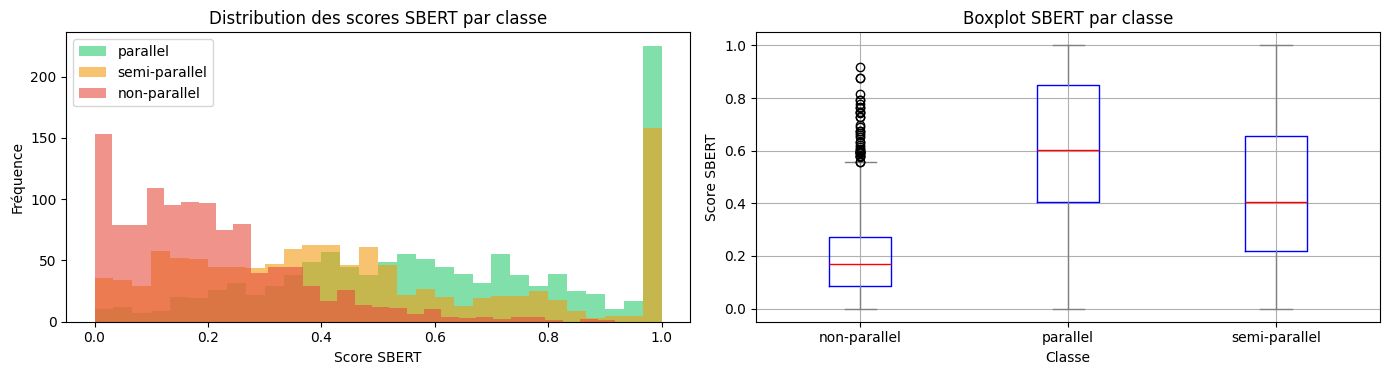

Figure sauvegardée : sbert_distribution.png


In [11]:
# Distribution des scores SBERT par classe
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = {"parallel": "#2ecc71", "semi-parallel": "#f39c12", "non-parallel": "#e74c3c"}

# Histogrammes
for cls, color in colors.items():
    subset = df[df["class"] == cls]["sbert_score"]
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=cls)
axes[0].set_title("Distribution des scores SBERT par classe")
axes[0].set_xlabel("Score SBERT")
axes[0].set_ylabel("Fréquence")
axes[0].legend()

# Boxplots
df.boxplot(column="sbert_score", by="class", ax=axes[1],
           color=dict(boxes="blue", medians="red", whiskers="gray", caps="gray"))
axes[1].set_title("Boxplot SBERT par classe")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Score SBERT")
plt.suptitle("")
plt.tight_layout()
plt.savefig("sbert_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : sbert_distribution.png")

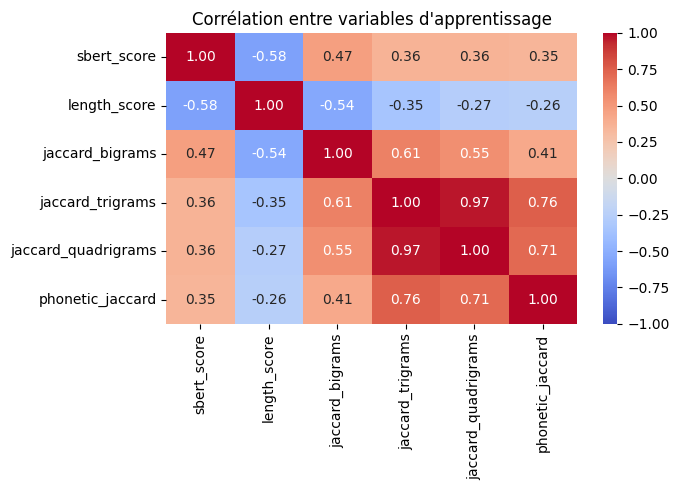

In [12]:
# Matrice de corrélation entre variables
corr = df[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1)
ax.set_title("Corrélation entre variables d'apprentissage")
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Préparation des données

In [13]:
X = df[FEATURE_COLS].values

# --- Cible binaire : 1 = parallèle ou semi-parallèle | 0 = non-parallèle ---
y_bin = df["binary_class"].values

# --- Cible multiclasse ---
le = LabelEncoder()
y_mc = le.fit_transform(df["class"])          # 0=non-parallel, 1=parallel, 2=semi-parallel
print("Encodage des classes :", dict(zip(le.classes_, le.transform(le.classes_))))

# --- Séparation entraînement / test (stratifiée sur les 3 classes) ---
X_train, X_test, y_bin_train, y_bin_test, y_mc_train, y_mc_test = train_test_split(
    X, y_bin, y_mc,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_mc
)

# --- Normalisation ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
joblib.dump(scaler, SCALER_PATH)

print(f"\nEntraînement : {X_train_sc.shape[0]} paires")
print(f"Test         : {X_test_sc.shape[0]} paires")

Encodage des classes : {'non-parallel': np.int64(0), 'parallel': np.int64(1), 'semi-parallel': np.int64(2)}

Entraînement : 2748 paires
Test         : 687 paires


## 3. Entraînement

### 3.1 Modèle binaire (parallèle/semi-parallèle vs non-parallèle)

In [14]:
logreg_bin = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    solver="lbfgs",
)
logreg_bin.fit(X_train_sc, y_bin_train)
joblib.dump(logreg_bin, MODEL_BIN_PATH)
print(f"Modèle binaire sauvegardé : {MODEL_BIN_PATH}")

# Validation croisée 5-fold
cv_scores = cross_val_score(logreg_bin, X_train_sc, y_bin_train, cv=5, scoring="f1")
print(f"F1 CV 5-fold (entraînement) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Modèle binaire sauvegardé : logreg_binary.joblib
F1 CV 5-fold (entraînement) : 0.8353 ± 0.0113


### 3.2 Modèle multiclasse (parallel / semi-parallel / non-parallel)

In [15]:
logreg_mc = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    multi_class="multinomial",
    random_state=RANDOM_STATE,
    solver="lbfgs",
)
logreg_mc.fit(X_train_sc, y_mc_train)
joblib.dump(logreg_mc, MODEL_MC_PATH)
print(f"Modèle multiclasse sauvegardé : {MODEL_MC_PATH}")

cv_mc = cross_val_score(logreg_mc, X_train_sc, y_mc_train, cv=5, scoring="f1_macro")
print(f"F1-macro CV 5-fold (entraînement) : {cv_mc.mean():.4f} ± {cv_mc.std():.4f}")

Modèle multiclasse sauvegardé : logreg_multiclass.joblib
F1-macro CV 5-fold (entraînement) : 0.7312 ± 0.0139


## 4. Évaluation

### 4.1 Modèle binaire

=== Rapport de classification (binaire) ===
                          precision    recall  f1-score   support

           non-parallèle       0.62      0.90      0.73       229
parallèle/semi-parallèle       0.93      0.73      0.82       458

                accuracy                           0.78       687
               macro avg       0.78      0.81      0.78       687
            weighted avg       0.83      0.78      0.79       687



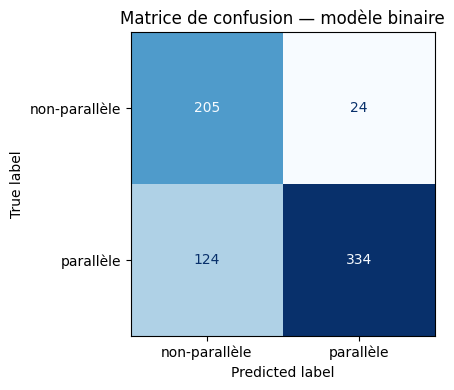

In [16]:
y_bin_pred  = logreg_bin.predict(X_test_sc)
y_bin_proba = logreg_bin.predict_proba(X_test_sc)[:, 1]

print("=== Rapport de classification (binaire) ===")
print(classification_report(y_bin_test, y_bin_pred,
                             target_names=["non-parallèle", "parallèle/semi-parallèle"]))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_bin_test, y_bin_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["non-parallèle", "parallèle"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matrice de confusion — modèle binaire")
plt.tight_layout()
plt.savefig("confusion_binary.png", dpi=150, bbox_inches="tight")
plt.show()

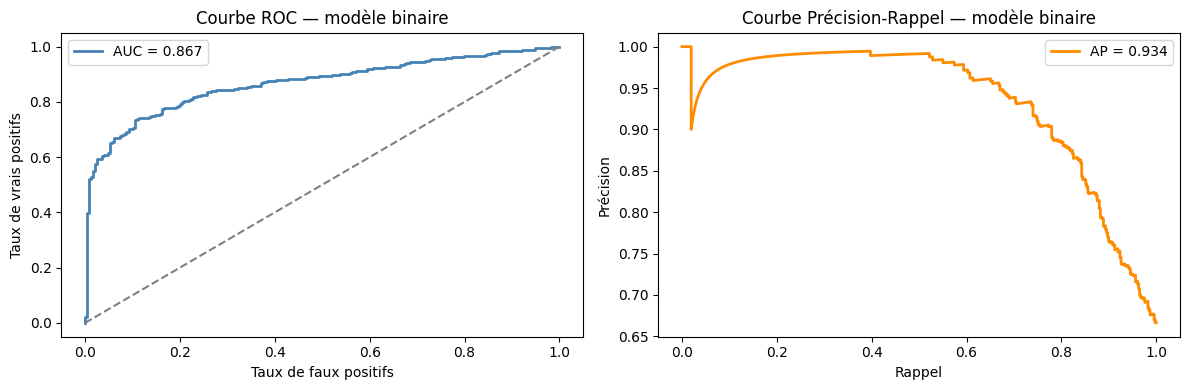

AUC-ROC : 0.8669 | Average Precision : 0.9338


In [17]:
# Courbe ROC
fpr, tpr, _ = roc_curve(y_bin_test, y_bin_proba)
auc_score   = roc_auc_score(y_bin_test, y_bin_proba)

# Courbe Précision-Rappel
prec, rec, _ = precision_recall_curve(y_bin_test, y_bin_proba)
ap_score     = average_precision_score(y_bin_test, y_bin_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc_score:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("Taux de faux positifs")
axes[0].set_ylabel("Taux de vrais positifs")
axes[0].set_title("Courbe ROC — modèle binaire")
axes[0].legend()

axes[1].plot(rec, prec, color="darkorange", lw=2, label=f"AP = {ap_score:.3f}")
axes[1].set_xlabel("Rappel")
axes[1].set_ylabel("Précision")
axes[1].set_title("Courbe Précision-Rappel — modèle binaire")
axes[1].legend()

plt.tight_layout()
plt.savefig("roc_pr_binary.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"AUC-ROC : {auc_score:.4f} | Average Precision : {ap_score:.4f}")

### 4.2 Modèle multiclasse

=== Rapport de classification (multiclasse) ===
               precision    recall  f1-score   support

 non-parallel       0.67      0.78      0.72       229
     parallel       0.77      0.91      0.83       229
semi-parallel       0.77      0.50      0.60       229

     accuracy                           0.73       687
    macro avg       0.73      0.73      0.72       687
 weighted avg       0.73      0.73      0.72       687



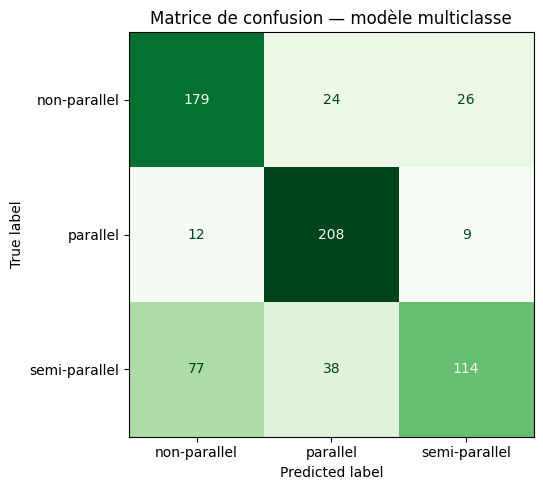

In [18]:
y_mc_pred = logreg_mc.predict(X_test_sc)

print("=== Rapport de classification (multiclasse) ===")
print(classification_report(y_mc_test, y_mc_pred, target_names=le.classes_))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
cm_mc = confusion_matrix(y_mc_test, y_mc_pred)
disp_mc = ConfusionMatrixDisplay(cm_mc, display_labels=le.classes_)
disp_mc.plot(ax=ax, colorbar=False, cmap="Greens")
ax.set_title("Matrice de confusion — modèle multiclasse")
plt.tight_layout()
plt.savefig("confusion_multiclass.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.3 Importance des variables

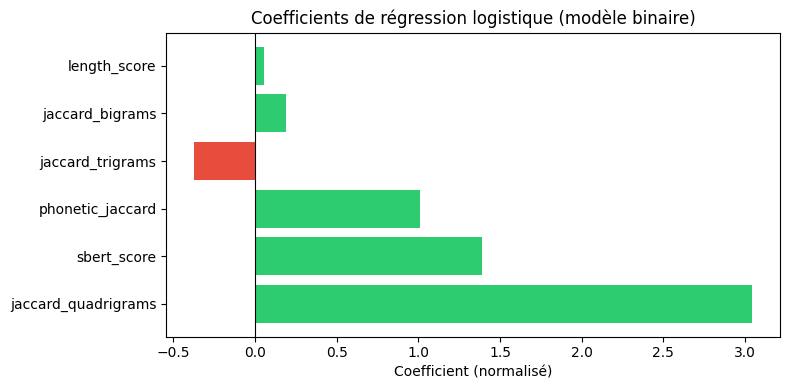

           variable  coefficient
jaccard_quadrigrams     3.043019
        sbert_score     1.390355
   phonetic_jaccard     1.008419
   jaccard_trigrams    -0.372198
    jaccard_bigrams     0.192637
       length_score     0.056683


In [19]:
# Coefficients du modèle binaire
coef_df = pd.DataFrame({
    "variable":   FEATURE_COLS,
    "coefficient": logreg_bin.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = ["#2ecc71" if c > 0 else "#e74c3c" for c in coef_df["coefficient"]]
ax.barh(coef_df["variable"], coef_df["coefficient"], color=colors_bar)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Coefficients de régression logistique (modèle binaire)")
ax.set_xlabel("Coefficient (normalisé)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(coef_df.to_string(index=False))

### 4.4 Performances par langue régionale

In [20]:
from sklearn.metrics import f1_score, accuracy_score

# Récupère les indices du jeu de test
idx_test = df.index[len(X_train):len(X_train) + len(X_test)]

# Reconstruit un DataFrame de test annoté
_, df_test_raw = train_test_split(
    df, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_mc
)
df_test_raw = df_test_raw.copy()
df_test_raw["pred_bin"]  = y_bin_pred
df_test_raw["true_bin"]  = y_bin_test
df_test_raw["pred_class"] = le.inverse_transform(y_mc_pred)

results_by_lang = []
for lang in ["co", "gsw", "oc"]:
    mask = df_test_raw["language"] == lang
    if mask.sum() == 0:
        continue
    sub = df_test_raw[mask]
    f1  = f1_score(sub["true_bin"], sub["pred_bin"], zero_division=0)
    acc = accuracy_score(sub["true_bin"], sub["pred_bin"])
    results_by_lang.append({"Langue": lang, "N test": len(sub), "Accuracy": round(acc, 4), "F1": round(f1, 4)})

lang_df = pd.DataFrame(results_by_lang)
print("=== Performances par langue régionale (modèle binaire) ===")
print(lang_df.to_string(index=False))

=== Performances par langue régionale (modèle binaire) ===
Langue  N test  Accuracy     F1
    co     233    0.8197 0.8489
   gsw     127    0.6299 0.6569
    oc     143    0.9301 0.9462


## 5. Sauvegarde et résumé

In [21]:
print("Fichiers sauvegardés :")
for f in [MODEL_BIN_PATH, MODEL_MC_PATH, SCALER_PATH]:
    print(f"  ✔ {f}")

print("\nFigures sauvegardées :")
for f in ["sbert_distribution.png", "feature_correlation.png",
          "confusion_binary.png", "roc_pr_binary.png",
          "confusion_multiclass.png", "feature_importance.png"]:
    print(f"  ✔ {f}")

Fichiers sauvegardés :
  ✔ logreg_binary.joblib
  ✔ logreg_multiclass.joblib
  ✔ scaler.joblib

Figures sauvegardées :
  ✔ sbert_distribution.png
  ✔ feature_correlation.png
  ✔ confusion_binary.png
  ✔ roc_pr_binary.png
  ✔ confusion_multiclass.png
  ✔ feature_importance.png


## 6. Inférence sur de nouvelles paires

Cette section montre comment utiliser le modèle entraîné pour prédire si une nouvelle paire de phrases est parallèle, semi-parallèle ou non-parallèle.

Les fonctions de calcul des variables sont reprises du notebook de constitution du dataset.

In [22]:
try:
    import jellyfish
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "jellyfish", "-q"])
    import jellyfish

try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity as cos_sim
    _sbert_available = True
except ImportError:
    _sbert_available = False
    print("sentence-transformers non disponible — le score SBERT sera mis à 0.")

# -------------------------------------------------------
# Fonctions de calcul des variables (identiques au notebook de constitution)
# -------------------------------------------------------

def normalize(text):
    text = text.lower()
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    return text.translate(str.maketrans("", "", string.punctuation)).strip()

def length_score(s1, s2):
    n1, n2  = len(s1.split()), len(s2.split())
    max_len = max(n1, n2)
    return 0.0 if max_len == 0 else abs(n1 - n2) / max_len

def char_ngrams(text, n):
    t = normalize(text)
    return set(t[i:i+n] for i in range(len(t) - n + 1))

def jaccard_index(a, b):
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)

def jaccard_ngrams(s1, s2, n):
    return jaccard_index(char_ngrams(s1, n), char_ngrams(s2, n))

def metaphone_codes(text):
    codes = set()
    for word in normalize(text).split():
        try:
            code = jellyfish.metaphone(word)
            if code:
                codes.add(code)
        except Exception:
            pass
    return codes

def phonetic_jaccard(s1, s2):
    return jaccard_index(metaphone_codes(s1), metaphone_codes(s2))


# Chargement du modèle SBERT (une seule fois)
if _sbert_available:
    _sbert_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
    print("Modèle SBERT chargé.")

def compute_features(fr_sentence: str, lr_sentence: str) -> np.ndarray:
    """
    Calcule le vecteur de variables pour une paire de phrases.
    Retourne un array de forme (1, 6) prêt pour le classifieur.
    """
    if _sbert_available:
        emb1 = _sbert_model.encode([fr_sentence], convert_to_numpy=True)
        emb2 = _sbert_model.encode([lr_sentence], convert_to_numpy=True)
        sbert = float(max(0.0, cos_sim(emb1, emb2)[0][0]))
    else:
        sbert = 0.0

    return np.array([[
        sbert,
        length_score(fr_sentence, lr_sentence),
        jaccard_ngrams(fr_sentence, lr_sentence, 2),
        jaccard_ngrams(fr_sentence, lr_sentence, 3),
        jaccard_ngrams(fr_sentence, lr_sentence, 4),
        phonetic_jaccard(fr_sentence, lr_sentence),
    ]])


def predict_pair(fr_sentence: str, lr_sentence: str, mode: str = "binary") -> dict:
    """
    Prédit si une paire de phrases est parallèle, semi-parallèle ou non-parallèle.

    Paramètres
    ----------
    fr_sentence : str   Phrase en français
    lr_sentence : str   Phrase en langue régionale
    mode        : str   'binary' (parallèle vs non-parallèle)
                        'multiclass' (3 classes)

    Retourne
    --------
    dict avec clés : prediction, probability, features
    """
    # Chargement des modèles et du scaler
    scaler_     = joblib.load(SCALER_PATH)
    model_bin_  = joblib.load(MODEL_BIN_PATH)
    model_mc_   = joblib.load(MODEL_MC_PATH)

    feats = compute_features(fr_sentence, lr_sentence)
    feats_sc = scaler_.transform(feats)

    if mode == "binary":
        pred  = model_bin_.predict(feats_sc)[0]
        proba = model_bin_.predict_proba(feats_sc)[0]
        label = "parallèle / semi-parallèle" if pred == 1 else "non-parallèle"
        conf  = proba[pred]
    else:
        pred  = model_mc_.predict(feats_sc)[0]
        proba = model_mc_.predict_proba(feats_sc)[0]
        label = le.inverse_transform([pred])[0]
        conf  = proba[pred]

    return {
        "prediction":  label,
        "confidence":  round(float(conf), 4),
        "features":    dict(zip(FEATURE_COLS, feats[0].tolist())),
    }


print("Fonctions d'inférence prêtes.")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modèle SBERT chargé.
Fonctions d'inférence prêtes.


In [23]:
# -------------------------------------------------------
# Exemples d'inférence
# -------------------------------------------------------
test_pairs = [
    (
        "La bise et le soleil se disputaient, chacun assurant qu'il était le plus fort.",
        "La bisa e lo solelh se disputavan, cascun assegurant qu'èra lo mai fòrt.",   # occitan
        "Parallèle attendue"
    ),
    (
        "La bise et le soleil se disputaient, chacun assurant qu'il était le plus fort.",
        "La bisa e lo solelh se disputavan.",   # semi-parallèle (tronquée)
        "Semi-parallèle attendue"
    ),
    (
        "Le gouvernement a annoncé de nouvelles mesures économiques.",
        "U ghjornu hè bellu è u mare hè calmu.",   # corse, sans lien
        "Non-parallèle attendue"
    ),
    (
        "L'enseignement élémentaire est obligatoire.",
        "D'Grundschulbildig isch pflichtisch.",   # alsacien
        "Parallèle attendue"
    ),
]

print("=" * 70)
for fr, lr, expected in test_pairs:
    result_bin = predict_pair(fr, lr, mode="binary")
    result_mc  = predict_pair(fr, lr, mode="multiclass")
    print(f"[{expected}]")
    print(f"  FR : {fr[:70]}")
    print(f"  LR : {lr[:70]}")
    print(f"  Binaire     → {result_bin['prediction']}  (confiance : {result_bin['confidence']:.2%})")
    print(f"  Multiclasse → {result_mc['prediction']}  (confiance : {result_mc['confidence']:.2%})")
    print("-" * 70)

[Parallèle attendue]
  FR : La bise et le soleil se disputaient, chacun assurant qu'il était le pl
  LR : La bisa e lo solelh se disputavan, cascun assegurant qu'èra lo mai fòr
  Binaire     → parallèle / semi-parallèle  (confiance : 99.37%)
  Multiclasse → parallel  (confiance : 97.56%)
----------------------------------------------------------------------
[Semi-parallèle attendue]
  FR : La bise et le soleil se disputaient, chacun assurant qu'il était le pl
  LR : La bisa e lo solelh se disputavan.
  Binaire     → parallèle / semi-parallèle  (confiance : 96.15%)
  Multiclasse → semi-parallel  (confiance : 89.56%)
----------------------------------------------------------------------
[Non-parallèle attendue]
  FR : Le gouvernement a annoncé de nouvelles mesures économiques.
  LR : U ghjornu hè bellu è u mare hè calmu.
  Binaire     → non-parallèle  (confiance : 91.84%)
  Multiclasse → non-parallel  (confiance : 85.20%)
------------------------------------------------------------------

In [24]:
# -------------------------------------------------------
# Inférence sur un corpus comparable non aligné
# -------------------------------------------------------
# Remplacez ces listes par vos propres phrases pour tester sur un corpus réel.

french_sentences = [
    "La bise et le soleil se disputaient.",
    "Il était une fois un voyageur qui traversait la forêt.",
    "Le soleil brille sur les montagnes.",
]

regional_sentences = [
    "La bisa e lo solelh se disputavan.",
    "I soli brillanu sulle montagne.",
    "Era una volta un viandante che atravessava la forest.",
]

print("Prédictions sur corpus comparable (toutes combinaisons) :")
print(f"{'FR':<45} {'LR':<45} {'Classe':>20} {'Conf':>8}")
print("-" * 125)

records = []
for fr in french_sentences:
    for lr in regional_sentences:
        res = predict_pair(fr, lr, mode="multiclass")
        records.append({"fr": fr, "lr": lr, "classe": res["prediction"], "confiance": res["confidence"]})
        print(f"{fr[:44]:<45} {lr[:44]:<45} {res['prediction']:>20} {res['confidence']:>8.2%}")

results_df = pd.DataFrame(records)
parallel_candidates = results_df[results_df["classe"] != "non-parallel"]
print(f"\n→ {len(parallel_candidates)} paires candidates sur {len(records)} comparaisons.")

Prédictions sur corpus comparable (toutes combinaisons) :
FR                                            LR                                                          Classe     Conf
-----------------------------------------------------------------------------------------------------------------------------
La bise et le soleil se disputaient.          La bisa e lo solelh se disputavan.                        parallel   98.88%
La bise et le soleil se disputaient.          I soli brillanu sulle montagne.                       non-parallel   55.67%
La bise et le soleil se disputaient.          Era una volta un viandante che atravessava l          non-parallel   68.69%
Il était une fois un voyageur qui traversait  La bisa e lo solelh se disputavan.                    non-parallel   83.81%
Il était une fois un voyageur qui traversait  I soli brillanu sulle montagne.                       non-parallel   69.24%
Il était une fois un voyageur qui traversait  Era una volta un viandante che atraves